In [ ]:
# Import necessary libraries
import os
import numpy as np
from tensorflow.keras.callbacks import ModelCheckpoint
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense , Dropout
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Define paths to training and testing datasets
train_path = '/content/drive/MyDrive/tomato/train'
test_path = '/content/drive/MyDrive/tomato/val'

In [ ]:
train_gen = ImageDataGenerator(rescale=(1./255),horizontal_flip=True,shear_range=0.2,zoom_range = 0.2)
test_gen = ImageDataGenerator(rescale=(1./255))  #--> (0 to 255) convert to (0 to 1)

In [ ]:
train = train_gen.flow_from_directory( '/content/drive/MyDrive/tomato/train',
                                      target_size=(120, 120),
                                      class_mode='categorical',
                                      subset='training',
                                      batch_size=9)
test = test_gen.flow_from_directory('/content/drive/MyDrive/tomato/val',
                                    target_size=(120, 120),
                                      class_mode='categorical',
                                      batch_size=9)

Found 8999 images belonging to 9 classes.
Found 900 images belonging to 9 classes.


In [ ]:
train.class_indices

{'Tomato___Bacterial_spot': 0,
 'Tomato___Early_blight': 1,
 'Tomato___Late_blight': 2,
 'Tomato___Leaf_Mold': 3,
 'Tomato___Septoria_leaf_spot': 4,
 'Tomato___Target_Spot': 5,
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 6,
 'Tomato___Tomato_mosaic_virus': 7,
 'Tomato___healthy': 8}

In [ ]:
# CNN model
from tensorflow.keras.layers import Convolution2D,MaxPooling2D,Flatten,Dense,BatchNormalization,GlobalAveragePooling2D,Activation
from tensorflow.keras.models import Sequential

In [ ]:
model = Sequential()

# Block 0
model.add(Conv2D(64, (5, 5), strides=1, padding="same", input_shape=(120, 120, 3)))
model.add(BatchNormalization())
model.add(Activation("relu"))

# Block 1
model.add(Conv2D(64, (5, 5), strides=1, padding="same"))
model.add(MaxPooling2D((4, 4)))
model.add(BatchNormalization())
model.add(Activation("relu"))

# Block 2
model.add(Conv2D(128, (3, 3), strides=2, padding="same"))
model.add(MaxPooling2D((2, 2)))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(Dropout(0.1))  # Adjust dropout rate

# Block 3
model.add(Conv2D(256, (7, 7), strides=2, padding="same"))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(Dropout(0.2))  # Adjust dropout rate

# Block 4
model.add(Conv2D(512, (3, 3), strides=2, padding="same"))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(Dropout(0.25))  # Adjust dropout rate

# Block 5
model.add(Conv2D(512, (3, 3), strides=2, padding="same"))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(Dropout(0.15))  # Adjust dropout rate

# Global Average Pooling
model.add(GlobalAveragePooling2D())

# Fully connected layers
model.add(Dense(1024, activation="relu"))
model.add(BatchNormalization())
model.add(Dropout(0.3))  # Adjust dropout rate
model.add(Dense(512, activation="relu"))
model.add(BatchNormalization())
model.add(Dense(256, activation="relu"))
model.add(BatchNormalization())
model.add(Dropout(0.4))  # Adjust dropout rate

# Output layer
model.add(Dense(9, activation='softmax'))

model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 120, 120, 64)      4864      
                                                                 
 batch_normalization_9 (Bat  (None, 120, 120, 64)      256       
 chNormalization)                                                
                                                                 
 activation_6 (Activation)   (None, 120, 120, 64)      0         
                                                                 
 conv2d_7 (Conv2D)           (None, 120, 120, 64)      102464    
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 30, 30, 64)        0         
 g2D)                                                            
                                                                 
 batch_normalization_10 (Ba  (None, 30, 30, 64)       

In [ ]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
#performing early stopping to avoid overfitting
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor = 'val_accuracy', mode = 'max', patience = 20, verbose = 1, restore_best_weights = True)

In [ ]:
history = model.fit(train,batch_size=10,validation_data=test,epochs=50)

Epoch 1/50
1000/1000 [==============================] - 2034s 2s/step - loss: 1.8471 - accuracy: 0.3965 - val_loss: 3.8962 - val_accuracy: 0.3056
Epoch 2/50
1000/1000 [==============================] - 74s 74ms/step - loss: 1.1012 - accuracy: 0.6186 - val_loss: 1.7080 - val_accuracy: 0.4989
Epoch 3/50
1000/1000 [==============================] - 76s 76ms/step - loss: 0.8569 - accuracy: 0.7099 - val_loss: 0.7058 - val_accuracy: 0.7556
Epoch 4/50
1000/1000 [==============================] - 72s 72ms/step - loss: 0.7779 - accuracy: 0.7409 - val_loss: 0.8932 - val_accuracy: 0.6800
Epoch 5/50
1000/1000 [==============================] - 70s 70ms/step - loss: 0.6912 - accuracy: 0.7691 - val_loss: 2.7506 - val_accuracy: 0.4311
Epoch 6/50
1000/1000 [==============================] - 71s 71ms/step - loss: 0.6410 - accuracy: 0.7870 - val_loss: 0.4138 - val_accuracy: 0.8633
Epoch 7/50
1000/1000 [==============================] - 71s 71ms/step - loss: 0.5910 - accuracy: 0.8040 - val_loss: 1.7992 -

In [ ]:

model.save('/content/drive/MyDrive/Colab Notebooks/FinalDraft.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


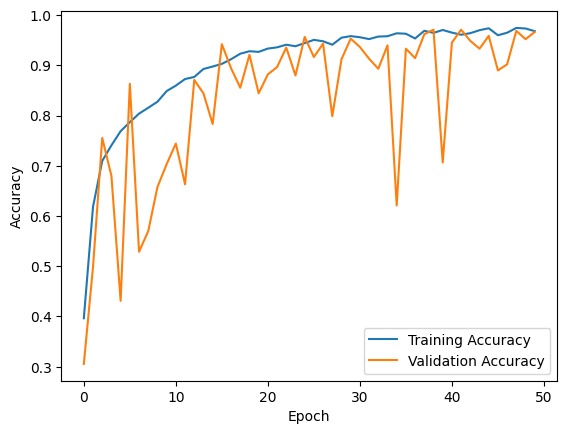

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

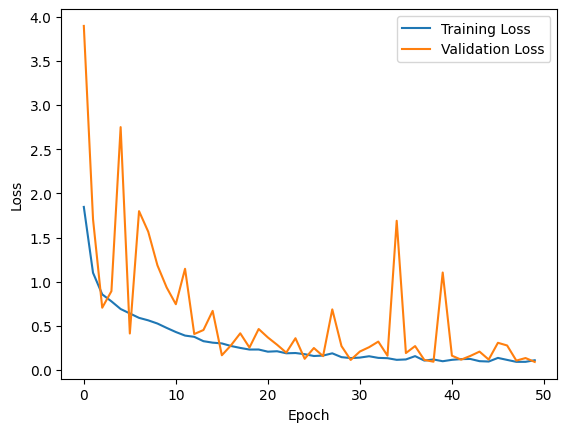

In [ ]:
# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# Evaluate the model on the validation generator
val_results = model.evaluate(test)

# Extract the metrics from the evaluation results
val_loss = val_results[0]
val_accuracy = val_results[1]

print(f'Validation Loss: {val_loss}')
print(f'Validation Accuracy: {val_accuracy}')

100/100 [==============================] - 3s 25ms/step - loss: 0.0921 - accuracy: 0.9667
Validation Loss: 0.09214633703231812
Validation Accuracy: 0.9666666388511658


In [ ]:
# Predict on the validation generator
val_pred = model.predict(test)

# Convert predicted probabilities to class labels
val_pred_classes = np.argmax(val_pred, axis=1)

# Assuming your validation labels are one-hot encoded
val_true_classes = test.classes

# Calculate metrics
accuracy = accuracy_score(val_true_classes, val_pred_classes)
precision = precision_score(val_true_classes, val_pred_classes, average='weighted')
recall = recall_score(val_true_classes, val_pred_classes, average='weighted')
f1 = f1_score(val_true_classes, val_pred_classes, average='weighted')

print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')

100/100 [==============================] - 3s 31ms/step
Accuracy: 0.10333333333333333
Precision: 0.10343878346905123
Recall: 0.10333333333333333
F1 Score: 0.10334009721913263


Confusion Matrix:
[[15 14 10 13 11  9  8 13  7]
 [17  8  8 14  9 15  7 11 11]
 [11  7 10 11 13 13 17  7 11]
 [11  8 10  8 12 12 12 13 14]
 [ 8 11 15 13 11 10 14 12  6]
 [10 12 11 10  9  7 13 11 17]
 [11 11 13  8 13 12 10 12 10]
 [ 8 14 14  8 15  8 12 11 10]
 [ 6  9 13  8 14 17  9 11 13]]


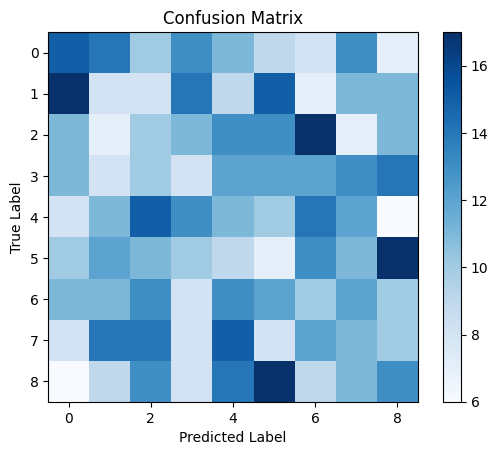

In [ ]:
# Confusion matrix
conf_matrix = confusion_matrix(val_true_classes, val_pred_classes)
print('Confusion Matrix:')
print(conf_matrix)

# Plot confusion matrix
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
from sklearn.metrics import  confusion_matrix


# Calculate sensitivity and specificity for each class
sensitivity_per_class = np.diag(conf_matrix) / np.sum(conf_matrix, axis=1)
specificity_per_class = np.diag(conf_matrix) / np.sum(conf_matrix, axis=0)

for i in range(len(sensitivity_per_class)):
    print(f'Class {i} - Sensitivity (Recall): {sensitivity_per_class[i]}, Specificity: {specificity_per_class[i]}')


Class 0 - Sensitivity (Recall): 0.15, Specificity: 0.15463917525773196
Class 1 - Sensitivity (Recall): 0.08, Specificity: 0.0851063829787234
Class 2 - Sensitivity (Recall): 0.1, Specificity: 0.09615384615384616
Class 3 - Sensitivity (Recall): 0.08, Specificity: 0.08602150537634409
Class 4 - Sensitivity (Recall): 0.11, Specificity: 0.102803738317757
Class 5 - Sensitivity (Recall): 0.07, Specificity: 0.06796116504854369
Class 6 - Sensitivity (Recall): 0.1, Specificity: 0.09803921568627451
Class 7 - Sensitivity (Recall): 0.11, Specificity: 0.10891089108910891
Class 8 - Sensitivity (Recall): 0.13, Specificity: 0.13131313131313133


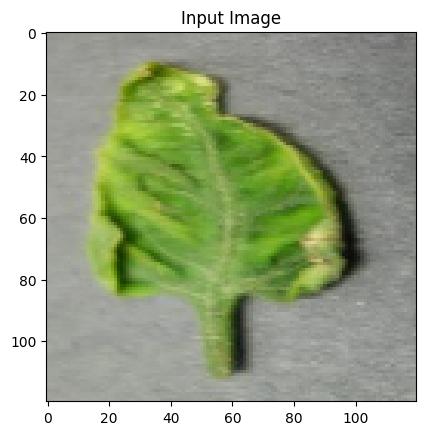

1/1 [==============================] - 1s 593ms/step
[[1.4295102e-04 5.9881486e-04 6.0227173e-03 2.1286489e-07 2.1022236e-12
  8.1237895e-06 9.9322695e-01 8.2641591e-09 2.1349473e-07]]
Predicted Class: Tomato___Tomato_Yellow_Leaf_Curl_Virus


In [ ]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Load the pre-trained model
model = load_model('/content/drive/MyDrive/FinalDraft.h5')

# Load and preprocess the input image
img_path = '/content/drive/MyDrive/tomato/train/Tomato___Tomato_Yellow_Leaf_Curl_Virus/cfbac9ed-82d2-4ccd-9a73-c97c0f92b2e2___UF.GRC_YLCV_Lab 02814.JPG'
img = image.load_img(img_path, target_size=(120, 120))

plt.imshow(img)
plt.title('Input Image')
plt.show()

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0

# Make prediction
predictions = model.predict(img_array)
print(predictions)

class_labels = list(train.class_indices.keys())
# Map predictions to class labels
predicted_class_index = np.argmax(predictions)
predicted_class_label = class_labels[predicted_class_index]

# Show the predicted class label
print(f'Predicted Class: {predicted_class_label}')
